In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/ilini/Desktop/ivan/study/pipeDream_experiments/pipedream_project


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.objectives.quadratic import QuadraticObjective
from src.schedulers.pipedream_1f1b import PipeDream1F1BScheduler, print_schedule, plot_schedule
from src.methods.pipedream import PipeDreamMethod
from src.methods.gpd import GPDMethod
from src.methods.sgd import SGDMethod
from src.experiments.runner import ExperimentRunner
from src.experiments.compare_methods import compare_methods
from src.plotting.convergence import plot_block_update_comparison
from src.utils.batching import build_training_batch_schedule
from src.state.timeline import num_microbatches_from_timeline

In [25]:
def make_pd_method(
    lr: float,
    timeline,
    training_batch_indices,
    init_stage_weights,
    name: str | None = None,
):
    return PipeDreamMethod(
        timeline=timeline,
        learning_rate=lr,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"PipeDream lr={lr:.3e}",
    )


def make_gpd_method(
    lr: float,
    K_budget: int,
    delta: int,
    training_batch_indices,
    init_stage_weights,
    seed: int,
    name: str | None = None,
):
    return GPDMethod(
        num_iterations=K_budget,
        learning_rate=lr,
        delta=delta,
        seed=seed,
        stage_sampling="uniform",
        batch_sampling="uniform",
        stale_sampling="uniform",

        timeline=timeline,
        
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"GPD lr={lr:.3e}",
    )

def run_trials(objective, method_factory, seeds):
    traces = []
    for seed in seeds:
        method = method_factory(seed)
        trace = method.run(objective)
        traces.append(trace)
    return traces


def aggregate_block_curves(traces, K_budget: int):
    curves = []
    for tr in traces:
        curve = tr.block_update_objective
        if curve is None:
            raise ValueError(f"{tr.method_name} has no block_update_objective.")
        if len(curve) < K_budget:
            raise ValueError(f"Curve too short: len={len(curve)}, required {K_budget}")
        curves.append(curve[:K_budget])
    curves = np.stack(curves, axis=0)
    return {
        "mean": curves.mean(axis=0),
        "std": curves.std(axis=0),
        "final_mean": float(curves[:, -1].mean()),
        "final_std": float(curves[:, -1].std()),
        "all": curves,
    }

def sweep_learning_rates(
    objective,
    method_name: str,
    learning_rates,
    method_factory_builder,
    seeds,
    K_budget: int,
):
    results = {}

    for lr in learning_rates:
        traces = run_trials(
            objective=objective,
            method_factory=lambda seed, lr=lr: method_factory_builder(lr, seed),
            seeds=seeds,
        )
        agg = aggregate_block_curves(traces, K_budget=K_budget)
        results[float(lr)] = {
            "traces": traces,
            "mean_curve": agg["mean"],
            "std_curve": agg["std"],
            "final_mean": agg["final_mean"],
            "final_std": agg["final_std"],
        }

    best_lr = min(results.keys(), key=lambda lr: results[lr]["final_mean"])
    return {
        "method_name": method_name,
        "results": results,
        "best_lr": best_lr,
        "best_curve": results[best_lr]["mean_curve"],
        "best_std": results[best_lr]["std_curve"],
    }


def plot_lr_sweep_curves(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
    log_scale: bool = False,
):
    plt.figure(figsize=(9, 5))
    eps = 1e-16

    for lr, info in sorted(sweep_result["results"].items(), key=lambda x: x[0]):
        y = np.maximum(info["mean_curve"], eps) if log_scale else info["mean_curve"]
        label = f"lr={lr:.3e}"
        if np.isclose(lr, sweep_result["best_lr"]):
            label += "  [best]"
            lw = 2.8
        elif reference_lr is not None and np.isclose(lr, reference_lr):
            label += f"  [{reference_label}]"
            lw = 2.8
        else:
            lw = 1.4

        if log_scale:
            plt.semilogy(y, label=label, linewidth=lw)
        else:
            plt.plot(y, label=label, linewidth=lw)

    plt.xlabel("number of block updates")
    plt.ylabel("full objective")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


def plot_lr_sweep_summary(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
):
    lrs = np.array(sorted(sweep_result["results"].keys()))
    means = np.array([sweep_result["results"][lr]["final_mean"] for lr in lrs])
    stds = np.array([sweep_result["results"][lr]["final_std"] for lr in lrs])

    plt.figure(figsize=(7, 4))
    plt.errorbar(lrs, means, yerr=stds, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("learning rate")
    plt.ylabel("final objective at fixed budget")
    plt.title(title)

    if reference_lr is not None:
        plt.axvline(reference_lr, linestyle="--", linewidth=1.5, label=reference_label)
        plt.legend()

    plt.tight_layout()
    plt.show()

In [3]:
# problem setup
num_stages = 10
delta_gpd = num_stages**2 - num_stages // 2  # from the theorem I proved

num_parameters = 50

batch_size = 10
total_batches = 10
num_epochs = 30
seed = 0

num_examples = batch_size * total_batches
num_microbatches = total_batches * num_epochs

objective = QuadraticObjective.synthetic(
    num_examples=num_examples,
    num_parameters=num_parameters,
    num_stages=num_stages,
    batch_size=batch_size,
    seed=seed,
    noise_std=0.0,
)

scheduler = PipeDream1F1BScheduler(noam=num_stages)
timeline = scheduler.generate(num_stages=num_stages, num_microbatches=num_microbatches)

init_stage_weights = objective.initial_stage_weights(mode="zeros", seed=0)

# fixed PipeDream batch order for fairness across PipeDream LR sweeps
num_dataset_batches = len(objective.get_batches())

training_batch_indices = build_training_batch_schedule(
    num_dataset_batches=num_dataset_batches,
    num_microbatches=num_microbatches,
    shuffle_each_epoch=False,
    seed=seed + 1,
)

print("num_dataset_batches =", num_dataset_batches)
print("effective epochs    =", num_microbatches / num_dataset_batches)
print("first training batches =", training_batch_indices[:min(20, len(training_batch_indices))])

# common block-update budget:
# PipeDream naturally defines it
pd_probe = make_pd_method(
    lr=1e-3,
    timeline=timeline,
    training_batch_indices=training_batch_indices,
    init_stage_weights=init_stage_weights,
    name="PipeDream probe",
).run(objective)

K_budget = len(pd_probe.block_update_objective)
print("K_budget =", K_budget)

# useful constants
L = objective.smoothness_constant

print("L =", L)
print("1/L =", 1 / L)

num_dataset_batches = 10
effective epochs    = 30.0
first training batches = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


NameError: name 'make_pd_method' is not defined

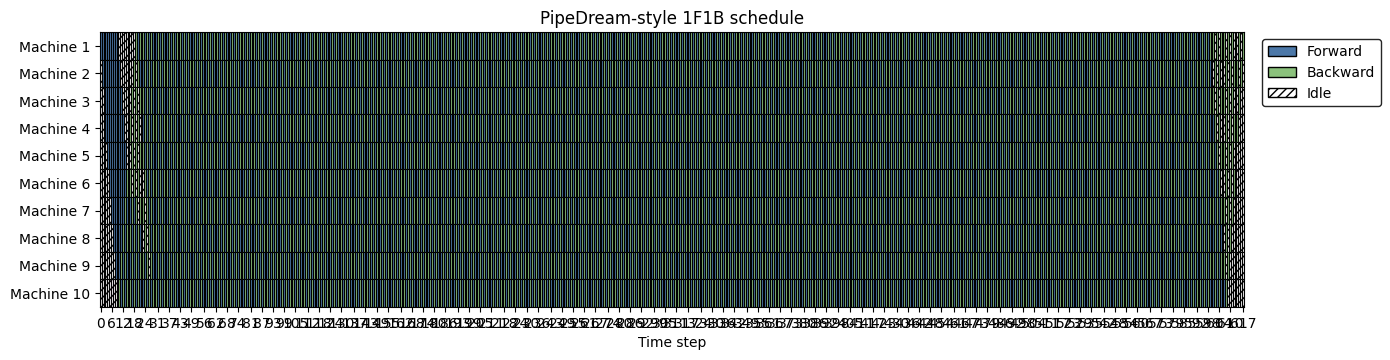

In [27]:
fig, ax = plot_schedule(timeline, startup_boundary=None, reduce_text=True, max_xtick_labels=100)
plt.show()

In [46]:
num_lr_points = 30
gamma_grid = np.linspace(0.01 / L, 0.2 / L, num_lr_points)

print("L =", L)
print("gamma min =", gamma_grid[0])
print("gamma max =", gamma_grid[-1])
print("1/L =", 1.0 / L)

pd_lrs = gamma_grid.copy()

pd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="PipeDream",
    learning_rates=pd_lrs,
    method_factory_builder=lambda lr, seed: make_pd_method(
        lr=lr,
        timeline=timeline,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=f"PipeDream lr={lr:.6e}",
    ),
    seeds=[0],
    K_budget=K_budget,
)

print("Best PipeDream lr =", pd_sweep["best_lr"])
print("Best PipeDream lr * L =", pd_sweep["best_lr"] * L)

L = 2.5816419150281793
gamma min = 0.0038735038898261953
gamma max = 0.0774700777965239
1/L = 0.38735038898261953
Best PipeDream lr = 0.0774700777965239
Best PipeDream lr * L = 0.19999999999999998


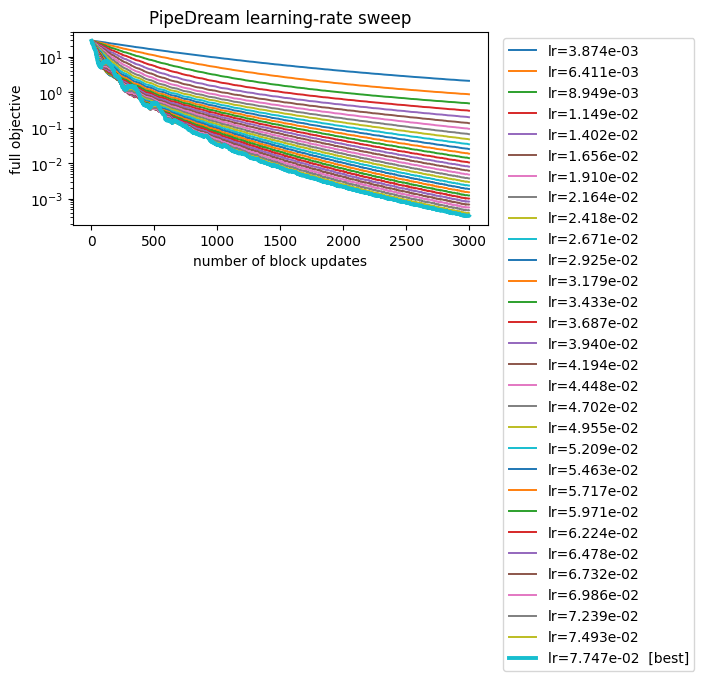

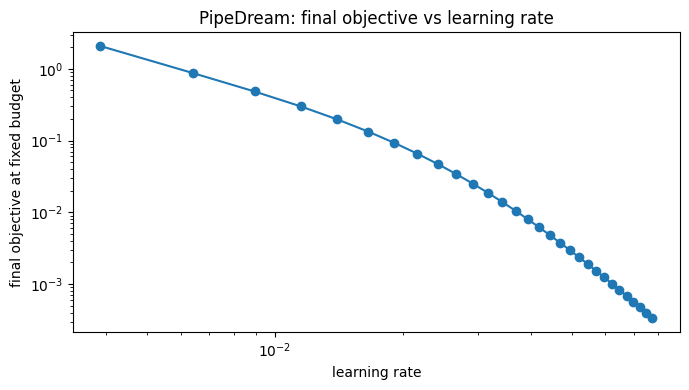

In [47]:
plot_lr_sweep_curves(
    pd_sweep,
    title="PipeDream learning-rate sweep",
    log_scale=True,
)

plot_lr_sweep_summary(
    pd_sweep,
    title="PipeDream: final objective vs learning rate",
)

In [44]:
gamma_grid = np.linspace(0.01 / L, 0.8 / L, num_lr_points)

gpd_lrs = gamma_grid.copy()

gpd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="GPD",
    learning_rates=gpd_lrs,
    method_factory_builder=lambda lr, seed: make_gpd_method(
        lr=lr,
        K_budget=K_budget,
        delta=delta_gpd,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        seed=seed,
        name=f"GPD lr={lr:.6e}",
    ),
    seeds=list(range(10)),
    K_budget=K_budget,
)

print("Best GPD lr =", gpd_sweep["best_lr"])
print("Best GPD lr * L =", gpd_sweep["best_lr"] * L)

KeyboardInterrupt: 

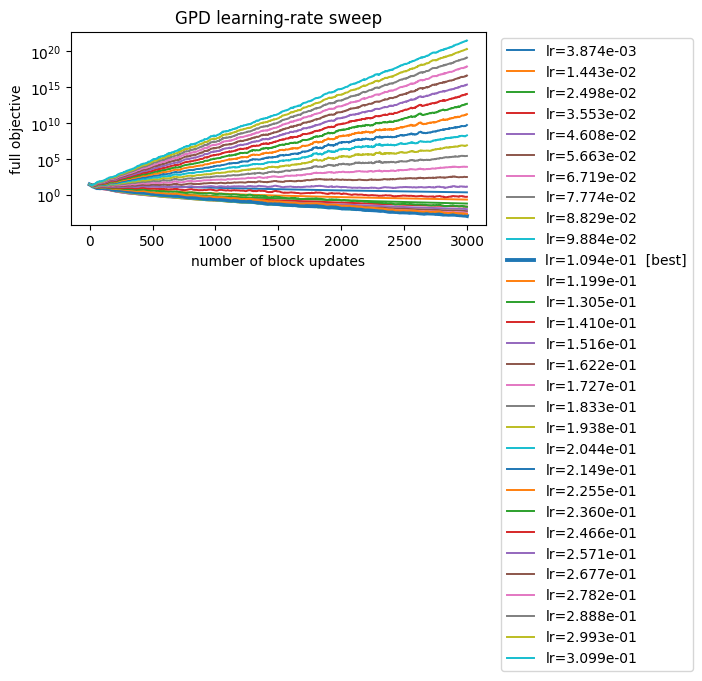

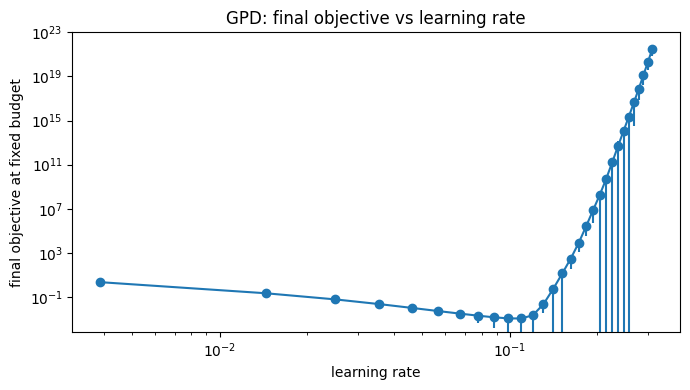

In [31]:
plot_lr_sweep_curves(
    gpd_sweep,
    title="GPD learning-rate sweep",
    log_scale=True,
)

plot_lr_sweep_summary(
    gpd_sweep,
    title="GPD: final objective vs learning rate",
)

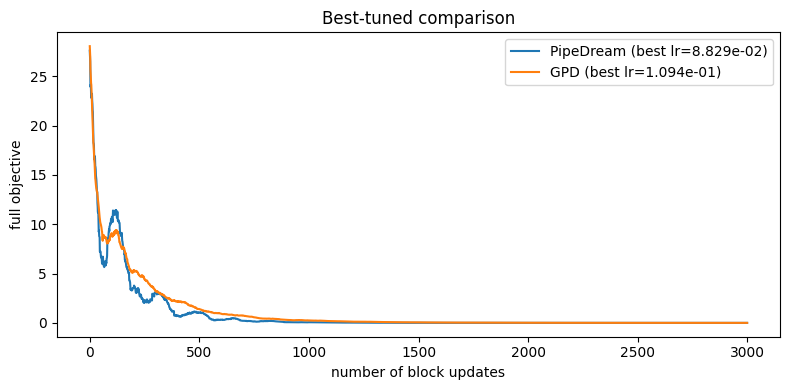

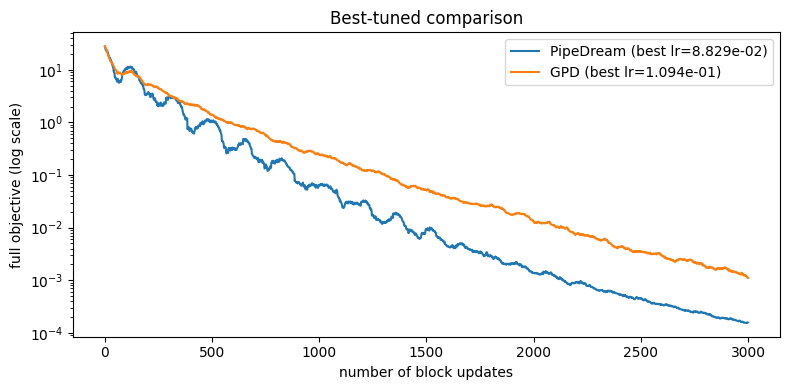

In [32]:
best_pd_curve = pd_sweep["best_curve"]
best_gpd_curve = gpd_sweep["best_curve"]

T = min(len(best_pd_curve), len(best_gpd_curve))

plt.figure(figsize=(8, 4))
plt.plot(best_pd_curve[:T], label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})")
plt.plot(best_gpd_curve[:T], label=f"GPD (best lr={gpd_sweep['best_lr']:.3e})")
plt.xlabel("number of block updates")
plt.ylabel("full objective")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
eps = 1e-16
plt.semilogy(np.maximum(best_pd_curve[:T], eps), label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})")
plt.semilogy(np.maximum(best_gpd_curve[:T], eps), label=f"GPD (best lr={gpd_sweep['best_lr']:.3e})")
plt.xlabel("number of block updates")
plt.ylabel("full objective (log scale)")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

## GPD comparison for multiple values of $\delta$

The cells below repeat the GPD learning-rate sweep for several different delay bounds
and then compare the best-tuned GPD curve for each $\delta$ against PipeDream.
This lets us see how sensitive the approximation is to the choice of $\delta$.

In [33]:
# choose several delta values to compare
raw_delta_candidates = [
    ("0", 0),
    (r"S/2", max(1, num_stages // 2)),
    (r"S", max(1, num_stages)),
    (r"S^2/4", max(1, num_stages**2 // 4)),
    (r"S^2/2", max(1, num_stages**2 // 2)),
    (r"S^2 - S/2", max(1, num_stages**2 - num_stages // 2)),
    (r"S^2", max(1, num_stages**2)),
]

delta_candidates = []
seen = set()
for label, delta in raw_delta_candidates:
    if delta not in seen:
        delta_candidates.append((label, int(delta)))
        seen.add(int(delta))

print("delta candidates:")
for label, delta in delta_candidates:
    print(f"  {label:>10s} -> {delta}")

delta candidates:
           0 -> 0
         S/2 -> 5
           S -> 10
       S^2/4 -> 25
       S^2/2 -> 50
   S^2 - S/2 -> 95
         S^2 -> 100


In [34]:
gpd_sweeps_by_delta = {}

for delta_label, delta_value in delta_candidates:
    print(f"Running GPD sweep for delta={delta_label} ({delta_value})")

    sweep = sweep_learning_rates(
        objective=objective,
        method_name=f"GPD delta={delta_label}",
        learning_rates=gamma_grid,
        method_factory_builder=lambda lr, seed, delta_value=delta_value, delta_label=delta_label: make_gpd_method(
            lr=lr,
            K_budget=K_budget,
            delta=delta_value,
            training_batch_indices=training_batch_indices,
            init_stage_weights=init_stage_weights,
            seed=seed,
            name=f"GPD delta={delta_label} lr={lr:.6e}",
        ),
        seeds=list(range(10)),
        K_budget=K_budget,
    )

    gpd_sweeps_by_delta[delta_value] = {
        "label": delta_label,
        "sweep": sweep,
    }

    print(
        f"  best lr = {sweep['best_lr']:.6e}, "
        f"best lr * L = {sweep['best_lr'] * L:.6e}, "
        f"final objective = {sweep['results'][sweep['best_lr']]['final_mean']:.6e}"
    )

Running GPD sweep for delta=0 (0)
  best lr = 2.465686e-01, best lr * L = 6.365517e-01, final objective = 8.117705e-07
Running GPD sweep for delta=S/2 (5)
  best lr = 2.149127e-01, best lr * L = 5.548276e-01, final objective = 3.268642e-06
Running GPD sweep for delta=S (10)
  best lr = 2.254646e-01, best lr * L = 5.820690e-01, final objective = 2.728388e-06
Running GPD sweep for delta=S^2/4 (25)
  best lr = 1.832568e-01, best lr * L = 4.731034e-01, final objective = 7.983071e-06
Running GPD sweep for delta=S^2/2 (50)
  best lr = 1.410490e-01, best lr * L = 3.641379e-01, final objective = 1.798370e-04
Running GPD sweep for delta=S^2 - S/2 (95)
  best lr = 1.093931e-01, best lr * L = 2.824138e-01, final objective = 1.108052e-03
Running GPD sweep for delta=S^2 (100)
  best lr = 9.884113e-02, best lr * L = 2.551724e-01, final objective = 1.451508e-03


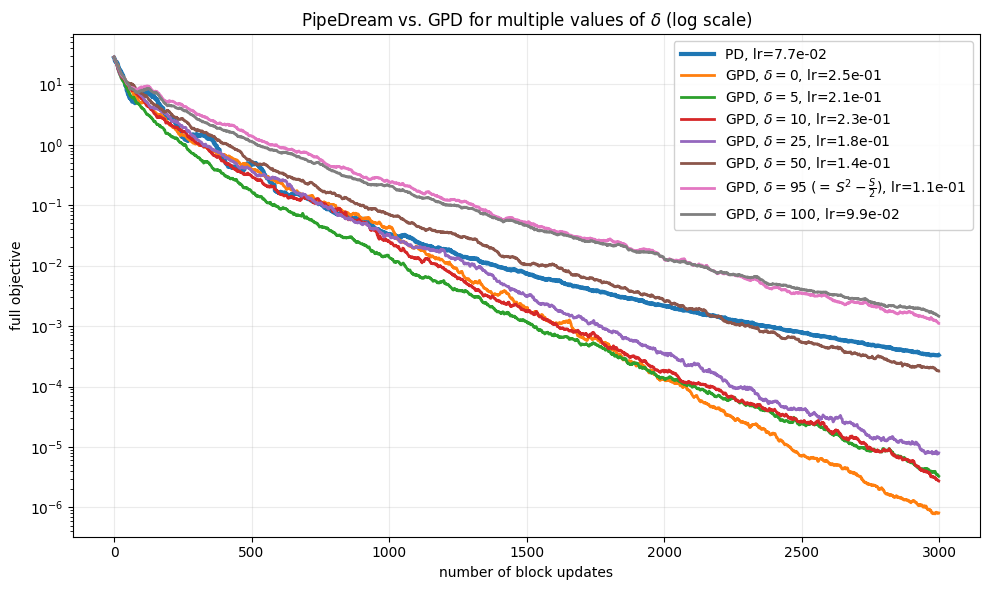

In [52]:
best_pd_curve = pd_sweep["best_curve"]
special_delta_value = num_stages**2 - num_stages / 2
eps = 1e-16

def format_delta_label(delta_value, special_delta_value):
    delta_int = int(round(delta_value))
    if np.isclose(delta_value, special_delta_value):
        return rf"{delta_int}\;(=\,S^2-\frac{{S}}{{2}})"
    return f"{delta_int}"

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(
    np.maximum(best_pd_curve, eps),
    linewidth=3.0,
    label=rf"PD, lr={pd_sweep['best_lr']:.1e}",
)

for delta_value, info in gpd_sweeps_by_delta.items():
    sweep = info["sweep"]
    curve = sweep["best_curve"]
    T = min(len(best_pd_curve), len(curve))
    delta_text = format_delta_label(delta_value, special_delta_value)

    ax.semilogy(
        np.maximum(curve[:T], eps),
        linewidth=2.0,
        label=rf"GPD, $\delta={delta_text}$, lr={sweep['best_lr']:.1e}",
    )

ax.set_xlabel("number of block updates")
ax.set_ylabel("full objective")
ax.set_title(r"PipeDream vs. GPD for multiple values of $\delta$ (log scale)")

ax.legend(
    loc="upper right",
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    borderpad=0.5,
    labelspacing=0.35,
    handlelength=2.4,
)

ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.savefig("pd_vs_GPD_different_delta.pdf", bbox_inches="tight")
plt.show()

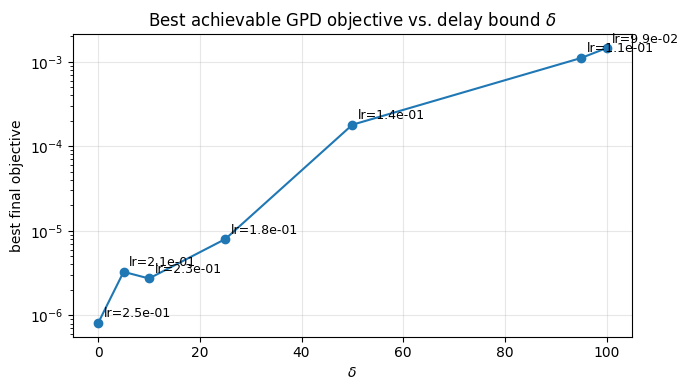

In [51]:
# summarize how the best achievable final objective depends on delta
delta_values = []
best_final_objectives = []
best_lrs_by_delta = []

for delta_value, info in sorted(gpd_sweeps_by_delta.items(), key=lambda x: x[0]):
    sweep = info["sweep"]
    best_lr = sweep["best_lr"]
    best_final = sweep["results"][best_lr]["final_mean"]

    delta_values.append(delta_value)
    best_final_objectives.append(best_final)
    best_lrs_by_delta.append(best_lr)

delta_values = np.asarray(delta_values)
best_final_objectives = np.asarray(best_final_objectives)
best_lrs_by_delta = np.asarray(best_lrs_by_delta)

plt.figure(figsize=(7, 4))
plt.semilogy(delta_values, best_final_objectives, marker="o")
for x, y, lr in zip(delta_values, best_final_objectives, best_lrs_by_delta):
    plt.annotate(f"lr={lr:.1e}", (x, y), textcoords="offset points", xytext=(4, 4), fontsize=9)
plt.xlabel(r"$\delta$")
plt.ylabel("best final objective")
plt.title(r"Best achievable GPD objective vs. delay bound $\delta$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("best_gpd_vs_delta.pdf", bbox_inches="tight")
plt.show()

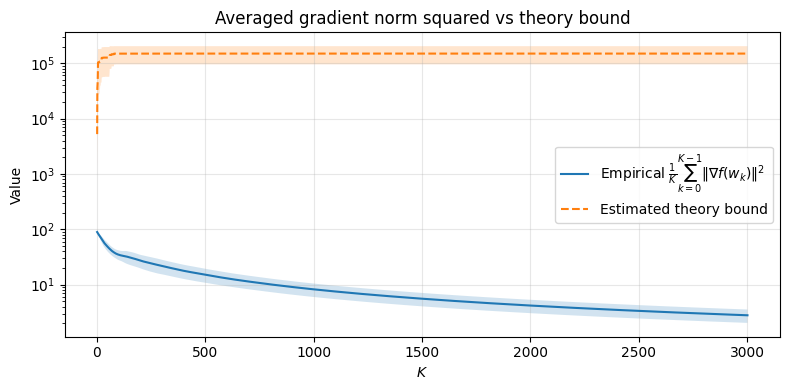

In [37]:
best_trace = gpd_sweep['results'][gpd_sweep['best_lr']]
traces = best_trace['traces']

avg_grad_curves = np.stack(
    [tr.avg_full_grad_norm_sq_trace for tr in traces],
    axis=0,
)
avg_grad_mean = avg_grad_curves.mean(axis=0)
avg_grad_std = avg_grad_curves.std(axis=0)

bound_curves = np.stack(
    [tr.theory_bound_trace for tr in traces],
    axis=0,
)
bound_mean = bound_curves.mean(axis=0)
bound_std = bound_curves.std(axis=0)

x = np.arange(1, len(avg_grad_mean) + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, avg_grad_mean, label=r"Empirical $\frac{1}{K}\sum_{k=0}^{K-1}\|\nabla f(w_k)\|^2$")
ax.fill_between(
    x,
    avg_grad_mean - avg_grad_std,
    avg_grad_mean + avg_grad_std,
    alpha=0.2,
)

ax.plot(x, bound_mean, linestyle="--", label=r"Estimated theory bound")
ax.fill_between(
    x,
    bound_mean - bound_std,
    bound_mean + bound_std,
    alpha=0.2,
)

ax.set_yscale("log")
ax.set_xlabel(r"$K$")
ax.set_ylabel("Value")
ax.set_title("Averaged gradient norm squared vs theory bound")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

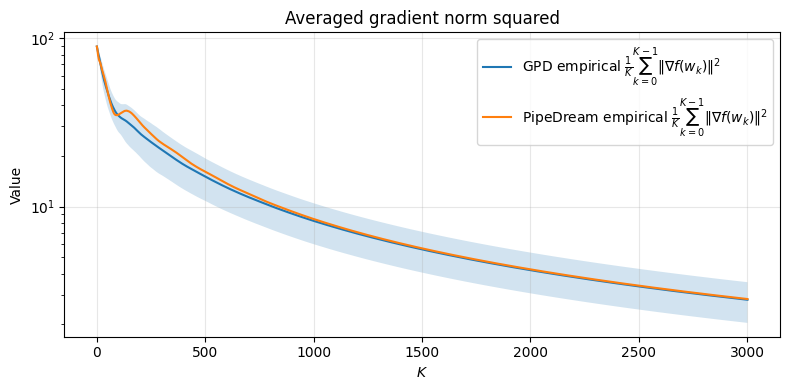

In [38]:
best_trace_gpd = gpd_sweep['results'][gpd_sweep['best_lr']]
gpd_traces = best_trace_gpd['traces']

avg_grad_curves_gpd = np.stack(
    [tr.avg_full_grad_norm_sq_trace for tr in gpd_traces],
    axis=0,
)
avg_grad_mean_gpd = avg_grad_curves_gpd.mean(axis=0)
avg_grad_std_gpd = avg_grad_curves_gpd.std(axis=0)

bound_curves_gpd = np.stack(
    [tr.theory_bound_trace for tr in gpd_traces],
    axis=0,
)
bound_mean_gpd = bound_curves_gpd.mean(axis=0)
bound_std_gpd = bound_curves_gpd.std(axis=0)


best_trace_pd = pd_sweep['results'][pd_sweep['best_lr']]
pd_traces = best_trace_pd['traces']

avg_grad_curves_pd = np.stack(
    [tr.avg_full_grad_norm_sq_trace for tr in pd_traces],
    axis=0,
)
avg_grad_mean_pd = avg_grad_curves_pd.mean(axis=0)
avg_grad_std_pd = avg_grad_curves_pd.std(axis=0)


x_gpd = np.arange(1, len(avg_grad_mean_gpd) + 1)
x_pd = np.arange(1, len(avg_grad_mean_pd) + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    x_gpd,
    avg_grad_mean_gpd,
    label=r"GPD empirical $\frac{1}{K}\sum_{k=0}^{K-1}\|\nabla f(w_k)\|^2$",
)
ax.fill_between(
    x_gpd,
    avg_grad_mean_gpd - avg_grad_std_gpd,
    avg_grad_mean_gpd + avg_grad_std_gpd,
    alpha=0.2,
)
'''
ax.plot(
    x_gpd,
    bound_mean_gpd,
    linestyle="--",
    label=r"GPD estimated theory bound",
)
ax.fill_between(
    x_gpd,
    bound_mean_gpd - bound_std_gpd,
    bound_mean_gpd + bound_std_gpd,
    alpha=0.2,
)'''

ax.plot(
    x_pd,
    avg_grad_mean_pd,
    label=r"PipeDream empirical $\frac{1}{K}\sum_{k=0}^{K-1}\|\nabla f(w_k)\|^2$",
)
ax.fill_between(
    x_pd,
    avg_grad_mean_pd - avg_grad_std_pd,
    avg_grad_mean_pd + avg_grad_std_pd,
    alpha=0.2,
)

ax.set_yscale("log")
ax.set_xlabel(r"$K$")
ax.set_ylabel("Value")
ax.set_title("Averaged gradient norm squared")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()